NeuroBridge AI - Model Training
   A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  A6_Score  A7_Score  \
0         1         1         1         1         0         0         1   
1         1         1         0         1         0         0         0   
2         1         1         0         1         1         0         1   
3         1         1         0         1         0         0         1   
4         1         0         0         0         0         0         0   

   A8_Score  A9_Score  A10_Score   age  gender  ethnicity  jundice  austim  \
0         1         0          0  26.0       0          9        0       0   
1         1         0          1  24.0       1          3        0       1   
2         1         1          1  27.0       1          3        1       1   
3         1         0          1  35.0       0          9        0       1   
4         1         0          0  40.0       0          9        0       0   

   contry_of_res  used_app_before  age_desc  rel

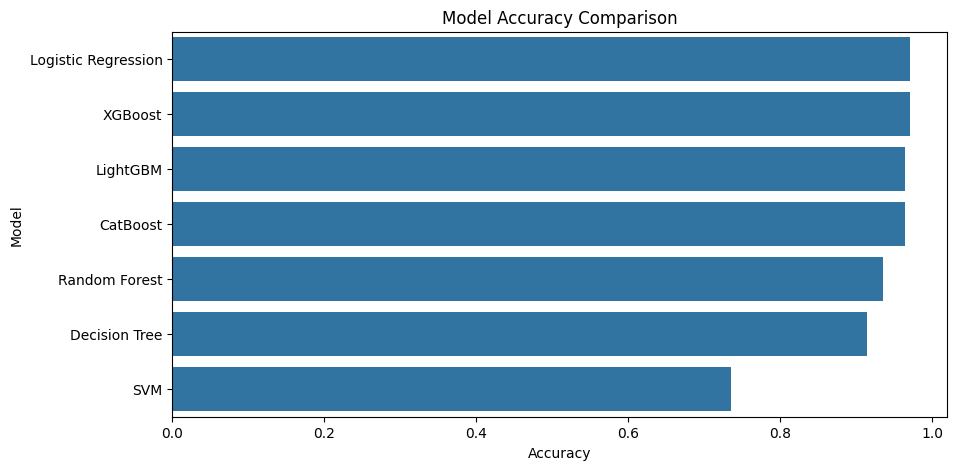


BEST MODEL
Model : Logistic Regression
Accuracy : 97.14 %

Saved Successfully
D:\AUTISM\backend\models\autism_model.pkl


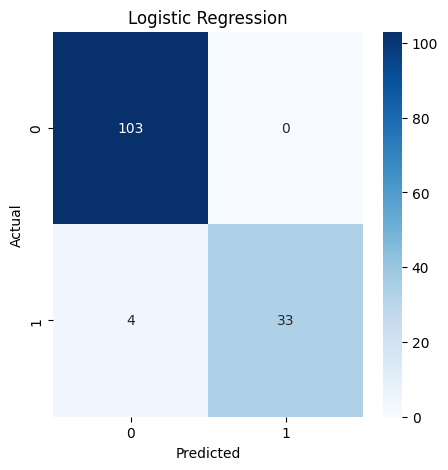


Results Saved
D:\AUTISM\backend\models\model_results.csv

MODEL TRAINING COMPLETED


In [2]:
# ==========================================================
# NeuroBridge AI
# 03_Model_Training.ipynb
#
# Machine Learning Model Training
# ==========================================================

# ==========================================================
# 1. IMPORT LIBRARIES
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

from catboost import CatBoostClassifier

print("="*70)
print("NeuroBridge AI - Model Training")
print("="*70)


# ==========================================================
# 2. LOAD DATASET
# ==========================================================

DATA_PATH = r"D:\AUTISM\datasets\questionaire\autism_clean.csv"

df = pd.read_csv(DATA_PATH)

print(df.head())


# ==========================================================
# 3. FEATURES & TARGET
# ==========================================================

X = df.drop("Class/ASD", axis=1)

y = df["Class/ASD"]

print()

print("Feature Shape :", X.shape)

print("Target Shape :", y.shape)


# ==========================================================
# 4. TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print()

print("Training Samples :", X_train.shape[0])

print("Testing Samples :", X_test.shape[0])


# ==========================================================
# 5. DEFINE MODELS
# ==========================================================

models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "SVM": SVC(probability=True),

    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ),

    "LightGBM": LGBMClassifier(),

    "CatBoost": CatBoostClassifier(
        verbose=0,
        random_state=42
    )
}


# ==========================================================
# 6. TRAIN MODELS
# ==========================================================

results = []

best_model = None

best_accuracy = 0

best_model_name = ""


for name, model in models.items():

    print()

    print("="*60)

    print(name)

    print("="*60)

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    precision = precision_score(y_test, prediction)

    recall = recall_score(y_test, prediction)

    f1 = f1_score(y_test, prediction)

    results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1

    })

    print(classification_report(y_test, prediction))

    if accuracy > best_accuracy:

        best_accuracy = accuracy

        best_model = model

        best_model_name = name


# ==========================================================
# 7. RESULTS TABLE
# ==========================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(

    by="Accuracy",

    ascending=False

)

print()

print("="*70)

print("MODEL COMPARISON")

print("="*70)

print(results_df)


# ==========================================================
# 8. BAR CHART
# ==========================================================

plt.figure(figsize=(10,5))

sns.barplot(

    data=results_df,

    x="Accuracy",

    y="Model"

)

plt.title("Model Accuracy Comparison")

plt.show()


# ==========================================================
# 9. SAVE RESULTS
# ==========================================================

os.makedirs(

    r"D:\AUTISM\backend\models",

    exist_ok=True

)

MODEL_PATH = r"D:\AUTISM\backend\models\autism_model.pkl"

joblib.dump(

    best_model,

    MODEL_PATH

)

print()

print("="*70)

print("BEST MODEL")

print("="*70)

print("Model :", best_model_name)

print("Accuracy :", round(best_accuracy*100,2), "%")

print()

print("Saved Successfully")

print(MODEL_PATH)


# ==========================================================
# 10. CONFUSION MATRIX
# ==========================================================

prediction = best_model.predict(X_test)

cm = confusion_matrix(

    y_test,

    prediction

)

plt.figure(figsize=(5,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(best_model_name)

plt.show()


# ==========================================================
# 11. FEATURE IMPORTANCE
# ==========================================================

if hasattr(best_model, "feature_importances_"):

    importance = pd.DataFrame({

        "Feature": X.columns,

        "Importance": best_model.feature_importances_

    })

    importance = importance.sort_values(

        by="Importance",

        ascending=False

    )

    print()

    print("="*70)

    print("TOP FEATURES")

    print("="*70)

    print(importance)

    plt.figure(figsize=(10,8))

    sns.barplot(

        data=importance,

        x="Importance",

        y="Feature"

    )

    plt.title("Feature Importance")

    plt.show()


# ==========================================================
# 12. SAVE METRICS
# ==========================================================

RESULT_PATH = r"D:\AUTISM\backend\models\model_results.csv"

results_df.to_csv(

    RESULT_PATH,

    index=False

)

print()

print("Results Saved")

print(RESULT_PATH)


# ==========================================================
# 13. FINISHED
# ==========================================================

print()

print("="*70)

print("MODEL TRAINING COMPLETED")

print("="*70)